# Archetypal SAEs ablations

In this notebook, we show the fatal flow of the archetypal SAEs https://arxiv.org/pdf/2502.12892
- The authors claim that the archetypal SAEs are more stable than standard ones, where stability measure how closes are dictionaries trained with a different seed
- However, we suspect that their setting is unfair: they always initialize archetypal SAEs the same while the standard SAEs are initialized at random
- We check that the stability comes solely from the initialization advantage and not al all from archetypal analysis

We test this conjecture by performing the following ablation studies:
- We check that the archetypal SAEs perform the same with archetypal projection switched off
- We check that the standard topK SAEs achieve the same good stability metric when we always initialize them at the k-means centroids and turn off normalization

For fair test, this notebook uses the code and the minimal example provided by the authors of the paper: https://github.com/KempnerInstitute/overcomplete

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# importing the minimal set of lib
# and download the small rabbit dataset

import torch
import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torchvision import transforms

import overcomplete
from overcomplete.metrics import cosine_hungarian_loss



## Load the dataset

In [3]:
# Uncomment for loading the dataset
!wget -O rabbit.npz -q "https://github.com/KempnerInstitute/Overcomplete/blob/main/docs/assets/rabbit.npz?raw=True"

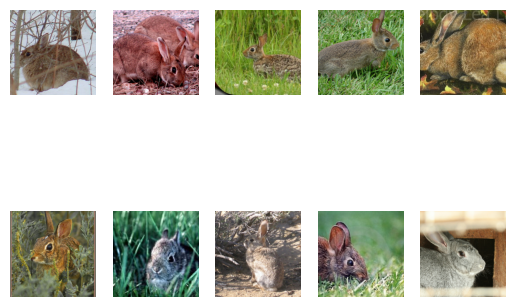

In [4]:
from overcomplete.visualization import show
# show is able to plot any numpy/pil/tensor and handle various
# data format (channel first, last, no channel...)

original_images = np.load('rabbit.npz')['arr_0'].astype(np.uint8)
for i in range(10):
  plt.subplot(2, 5, i+1)
  show(original_images[i])
plt.show()

## Load the DinoV2 vision encoder and get patch emebeddings

In [5]:
images = torch.Tensor(original_images).cuda()
images.shape
from overcomplete.models import DinoV2
model = DinoV2(device='cuda')

images = model.processor(images=images, return_tensors="pt").to("cuda")
last_hidden_states = model.forward_features(images)
patch_tokens = last_hidden_states[:,1:,:]

Activations = rearrange(patch_tokens, 'n t d -> (n t) d')
Activations.shape

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

torch.Size([76800, 384])

## Train archetypal SAE

### Get centroids from k-means

In [6]:
# before training our SAE, we need to capture "points" that will define the convex hull
# you can think of them as landmark that will guide the dictionary to be close to
# the activations regions.
# here we use kmeans, be sure to have more centroids than concepts.
# for large scale computation, we recommend to use faiss.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, verbose=1)
kmeans.fit(Activations.cpu())

centroids = kmeans.cluster_centers_
centroids.shape

Initialization complete
Iteration 0, inertia 131590999.18705195.
Iteration 1, inertia 84620089.85954756.
Iteration 2, inertia 82684422.6775969.
Iteration 3, inertia 81916421.3610689.
Iteration 4, inertia 81475818.08300844.
Iteration 5, inertia 81149856.6085808.
Iteration 6, inertia 80923110.39969611.
Iteration 7, inertia 80769088.87737885.
Iteration 8, inertia 80650009.81264941.
Iteration 9, inertia 80550080.34550026.
Iteration 10, inertia 80460655.16679545.
Iteration 11, inertia 80378051.91478807.
Iteration 12, inertia 80307172.87009501.
Iteration 13, inertia 80253016.3741061.
Iteration 14, inertia 80204560.79963039.
Iteration 15, inertia 80167241.33779037.
Iteration 16, inertia 80135341.09433445.
Iteration 17, inertia 80115058.85353583.
Iteration 18, inertia 80098313.0343229.
Iteration 19, inertia 80082952.28120703.
Iteration 20, inertia 80064886.35444954.
Iteration 21, inertia 80048749.62684765.
Iteration 22, inertia 80030610.83092004.
Iteration 23, inertia 80012741.26743284.
Iterat

(100, 384)

In [7]:
# now the funny part, lets train an archetypal topk sae
# we need a dataloader, a criterion and an optimizer
from torch.utils.data import DataLoader, TensorDataset
from overcomplete.sae import RATopKSAE, train_sae

sae = RATopKSAE(Activations.shape[-1], nb_concepts=30, top_k=3, points=torch.tensor(centroids).float().cuda(),
                delta=0.2, device='cuda')

dataloader = torch.utils.data.DataLoader(TensorDataset(Activations), batch_size=1024, shuffle=True)
optimizer = torch.optim.Adam(sae.parameters(), lr=5e-3)

def criterion(x, x_hat, pre_codes, codes, dictionary):
  loss = (x - x_hat).square().mean()

  # add reanimation loss to avoid dead codes:
  is_dead = ((codes > 0).sum(dim=0) == 0).float().detach()
  reanim_loss = (pre_codes * is_dead[None, :]).mean()
  loss -= reanim_loss * 1e-3

  return loss

In [8]:
logs = train_sae(sae, dataloader, criterion, optimizer, nb_epochs=30, device='cuda')

Epoch[1/30], Loss: 7.4063, R2: -0.1891, L0: 0.2395, Dead Features: 0.0%, Time: 0.5836 seconds
Epoch[2/30], Loss: 5.0629, R2: 0.1875, L0: 0.8982, Dead Features: 46.7%, Time: 0.2467 seconds
Epoch[3/30], Loss: 4.9330, R2: 0.2084, L0: 0.9947, Dead Features: 33.3%, Time: 0.1517 seconds
Epoch[4/30], Loss: 4.9283, R2: 0.2092, L0: 1.0011, Dead Features: 13.3%, Time: 0.1537 seconds
Epoch[5/30], Loss: 4.9421, R2: 0.2071, L0: 1.0020, Dead Features: 10.0%, Time: 0.2280 seconds
Epoch[6/30], Loss: 4.9249, R2: 0.2098, L0: 1.0057, Dead Features: 20.0%, Time: 0.1536 seconds
Epoch[7/30], Loss: 4.9183, R2: 0.2110, L0: 1.0312, Dead Features: 23.3%, Time: 0.2311 seconds
Epoch[8/30], Loss: 4.5085, R2: 0.2768, L0: 1.3163, Dead Features: 10.0%, Time: 0.1521 seconds
Epoch[9/30], Loss: 4.3939, R2: 0.2950, L0: 1.3761, Dead Features: 10.0%, Time: 0.1531 seconds
Epoch[10/30], Loss: 4.2920, R2: 0.3112, L0: 1.6388, Dead Features: 3.3%, Time: 0.2299 seconds
Epoch[11/30], Loss: 4.1654, R2: 0.3314, L0: 1.8114, Dead Fea

### Visualize SAE features as heatmaps

Concept 0


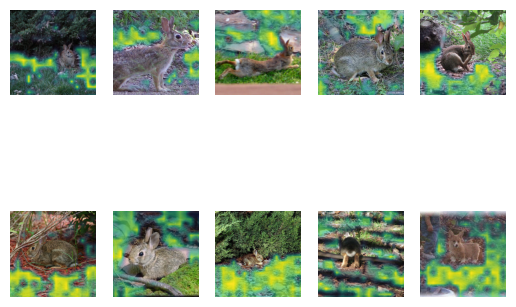

Concept 1


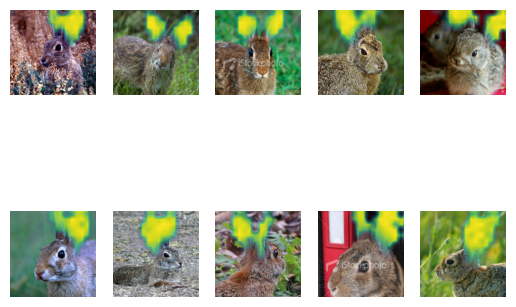

Concept 2


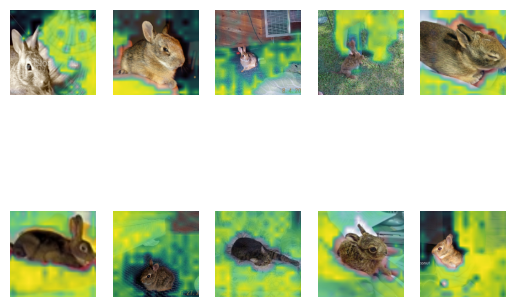

Concept 3


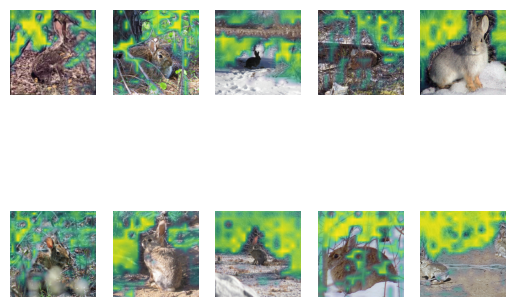

Concept 4


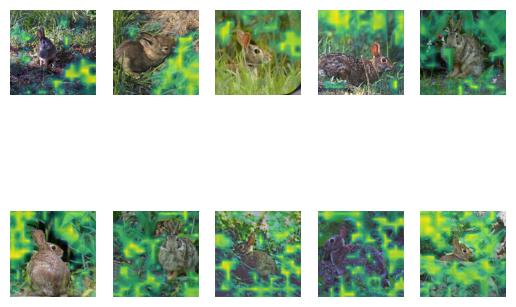

Concept 5


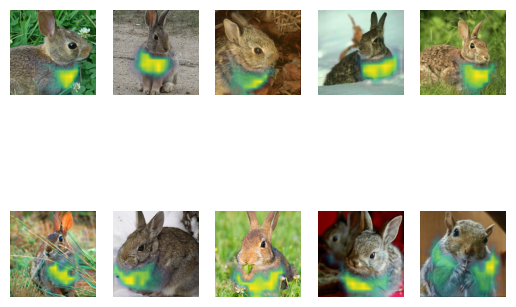

Concept 6


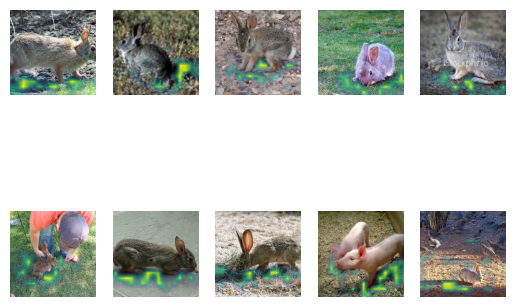

Concept 7


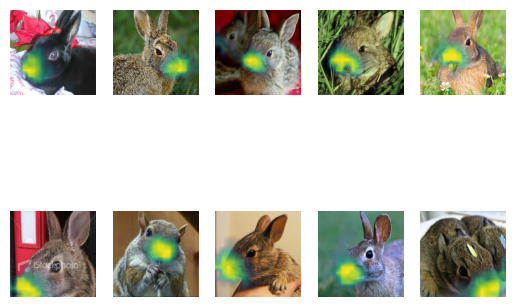

Concept 8


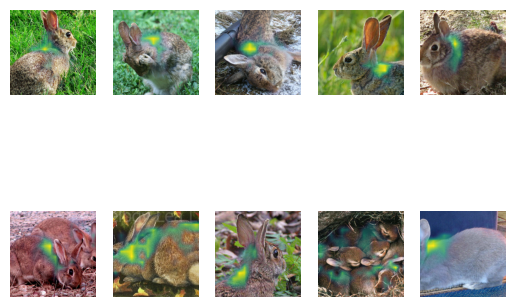

Concept 9


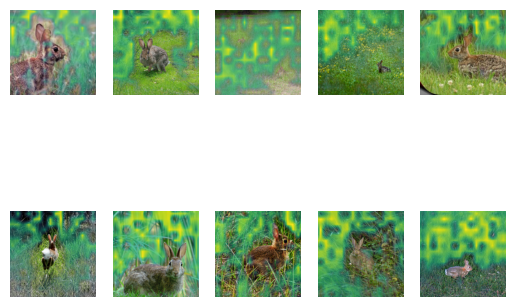

In [9]:
from overcomplete.visualization import overlay_top_heatmaps
# great, now let inspect the results !
# first we reshape the code to see them patch-wise
# then we will use `overlay_top_heatmaps`
# a little function to show the top concepts

sae = sae.eval()

with torch.no_grad():
  pre_codes, codes = sae.encode(Activations)

codes = rearrange(codes, '(n w h) d -> n w h d', w=16, h=16)

for i in range(10):
  print('Concept', i)
  overlay_top_heatmaps(original_images, codes, concept_id=i)
  plt.show()

## Measuring stability

### Train two classical topk saes on different seeds

In [10]:
# classical topk
from overcomplete.sae import TopKSAE

nb_concepts = 200

def train(sae):
  dataloader = torch.utils.data.DataLoader(TensorDataset(Activations), batch_size=1024, shuffle=True)
  optimizer = torch.optim.Adam(sae.parameters(), lr=5e-3)
  logs = train_sae(sae, dataloader, criterion, optimizer, nb_epochs=20, device='cuda')

sae1 = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda')
train(sae1)

sae2 = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda')
train(sae2)


Epoch[1/20], Loss: 3.3863, R2: 0.4559, L0: 3.0000, Dead Features: 0.0%, Time: 0.2770 seconds
Epoch[2/20], Loss: 2.5892, R2: 0.5839, L0: 3.0000, Dead Features: 1.0%, Time: 0.1453 seconds
Epoch[3/20], Loss: 2.4721, R2: 0.6026, L0: 3.0000, Dead Features: 1.0%, Time: 0.1465 seconds
Epoch[4/20], Loss: 2.3879, R2: 0.6161, L0: 3.0000, Dead Features: 0.5%, Time: 0.2226 seconds
Epoch[5/20], Loss: 2.3314, R2: 0.6252, L0: 3.0000, Dead Features: 0.0%, Time: 0.1456 seconds
Epoch[6/20], Loss: 2.2959, R2: 0.6309, L0: 3.0000, Dead Features: 0.0%, Time: 0.2211 seconds
Epoch[7/20], Loss: 2.2609, R2: 0.6365, L0: 3.0000, Dead Features: 0.0%, Time: 0.1442 seconds
Epoch[8/20], Loss: 2.2382, R2: 0.6402, L0: 3.0000, Dead Features: 0.0%, Time: 0.1468 seconds
Epoch[9/20], Loss: 2.2180, R2: 0.6434, L0: 3.0000, Dead Features: 0.0%, Time: 0.2212 seconds
Epoch[10/20], Loss: 2.1973, R2: 0.6468, L0: 3.0000, Dead Features: 0.0%, Time: 0.1450 seconds
Epoch[11/20], Loss: 2.1796, R2: 0.6496, L0: 3.0000, Dead Features: 0.

### Train two archetypal SAEs on different seeds

In [11]:
# now with archetypal
# classical topk
rasae1 = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1)
train(rasae1)

rasae2 = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1)
train(rasae2)


Epoch[1/20], Loss: 60.5146, R2: -8.7314, L0: 1.0608, Dead Features: 0.0%, Time: 0.2338 seconds
Epoch[2/20], Loss: 4.4247, R2: 0.2902, L0: 1.1731, Dead Features: 16.5%, Time: 0.1551 seconds
Epoch[3/20], Loss: 4.1013, R2: 0.3423, L0: 1.5256, Dead Features: 46.0%, Time: 0.1706 seconds
Epoch[4/20], Loss: 4.0431, R2: 0.3516, L0: 1.6903, Dead Features: 61.0%, Time: 0.2153 seconds
Epoch[5/20], Loss: 4.0228, R2: 0.3549, L0: 1.8101, Dead Features: 61.0%, Time: 0.1550 seconds
Epoch[6/20], Loss: 4.0151, R2: 0.3560, L0: 1.8233, Dead Features: 50.5%, Time: 0.2310 seconds
Epoch[7/20], Loss: 3.9905, R2: 0.3600, L0: 1.9649, Dead Features: 38.0%, Time: 0.1555 seconds
Epoch[8/20], Loss: 3.9931, R2: 0.3596, L0: 1.9957, Dead Features: 34.5%, Time: 0.2302 seconds
Epoch[9/20], Loss: 3.9740, R2: 0.3627, L0: 2.0939, Dead Features: 20.5%, Time: 0.1554 seconds
Epoch[10/20], Loss: 3.9806, R2: 0.3618, L0: 2.0837, Dead Features: 20.0%, Time: 0.1561 seconds
Epoch[11/20], Loss: 3.9707, R2: 0.3634, L0: 2.1222, Dead F

In [ ]:
d1, d2 = sae1.get_dictionary(), sae2.get_dictionary()
d3, d4 = rasae1.get_dictionary(), rasae2.get_dictionary()

score_classic_sae = cosine_hungarian_loss(d1.detach(), d2.detach()) / d1.shape[0]
score_archetypal_sae = cosine_hungarian_loss(d3.detach(), d4.detach()) / d1.shape[0]

print(f'Hungarian distance Classic SAE: {score_classic_sae}')
print(f'Hungarian distance Archetypal SAE: {score_archetypal_sae}')

Hungarian distance Classic SAE: 0.28335052490234375
Hungarian distance Archetypal SAE: 0.08699828147888183


Here the authors claim that the archetypal SAEs are more stable, in our ablations below we show that their argument is flawed and the stability improvements comes solely from fixing the dictionary initialization. It has nothing to do with their archetypal analysis.

### Turn off archetypal projection in archetypal SAEs

In [13]:
# now with archetypal
# classical topk
rasae1_ablated = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1, projection=False)
train(rasae1_ablated)

rasae2_ablated = RATopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', points=torch.tensor(centroids).float().cuda(), delta=0.1, projection=False)
train(rasae2_ablated)

d5, d6 = rasae1_ablated.get_dictionary(), rasae2_ablated.get_dictionary()
score_archetypal_sae_ablated = cosine_hungarian_loss(d5.detach(), d6.detach()) / nb_concepts
print(f'Hungarian distance Archetypal SAE Ablated: {score_archetypal_sae_ablated}')

Epoch[1/20], Loss: 4.7666, R2: 0.2344, L0: 3.0000, Dead Features: 0.0%, Time: 0.2186 seconds
Epoch[2/20], Loss: 2.5944, R2: 0.5833, L0: 3.0000, Dead Features: 23.0%, Time: 0.1398 seconds
Epoch[3/20], Loss: 2.4707, R2: 0.6035, L0: 3.0000, Dead Features: 20.0%, Time: 0.2163 seconds
Epoch[4/20], Loss: 2.3983, R2: 0.6153, L0: 3.0000, Dead Features: 25.0%, Time: 0.1409 seconds
Epoch[5/20], Loss: 2.3751, R2: 0.6192, L0: 3.0000, Dead Features: 25.5%, Time: 0.1415 seconds
Epoch[6/20], Loss: 2.3315, R2: 0.6263, L0: 3.0000, Dead Features: 33.5%, Time: 0.2155 seconds
Epoch[7/20], Loss: 2.3304, R2: 0.6266, L0: 3.0000, Dead Features: 32.5%, Time: 0.1392 seconds
Epoch[8/20], Loss: 2.2953, R2: 0.6324, L0: 3.0000, Dead Features: 33.5%, Time: 0.2151 seconds
Epoch[9/20], Loss: 2.2916, R2: 0.6330, L0: 3.0000, Dead Features: 33.5%, Time: 0.1409 seconds
Epoch[10/20], Loss: 2.2753, R2: 0.6357, L0: 3.0000, Dead Features: 38.5%, Time: 0.1449 seconds
Epoch[11/20], Loss: 2.2644, R2: 0.6375, L0: 3.0000, Dead Fea

## Fixing initialization of topk SAEs

In [14]:
C=torch.tensor(centroids).float().cuda()
nb_concepts = 200
nb_candidates = C.shape[0]
W = torch.eye(nb_concepts, nb_candidates, device="cuda")
D = W @ C
dictionary_params = {"initializer": D, "normalization": "identity"}

In [15]:
sae1_fixed_init = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', dictionary_params=dictionary_params)
train(sae1_fixed_init)

sae2_fixed_init = TopKSAE(Activations.shape[-1], nb_concepts=nb_concepts, top_k=3, device='cuda', dictionary_params=dictionary_params)
train(sae2_fixed_init)

d7, d8 = sae1_fixed_init.get_dictionary(), sae2_fixed_init.get_dictionary()
score_classic_sae_fixed_init = cosine_hungarian_loss(d7.detach(), d8.detach()) / nb_concepts
print(f'Hungarian distance Classic SAE with fixed init: {score_classic_sae_fixed_init}')

Epoch[1/20], Loss: 4.4305, R2: 0.2878, L0: 3.0000, Dead Features: 0.0%, Time: 0.1451 seconds


/home/user/projects/ablating-archetypes/overcomplete/sae/dictionary.py:154: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self._weights.data = torch.tensor(initializer, device=device)


Epoch[2/20], Loss: 2.5168, R2: 0.5958, L0: 3.0000, Dead Features: 27.5%, Time: 0.1427 seconds
Epoch[3/20], Loss: 2.4204, R2: 0.6115, L0: 3.0000, Dead Features: 20.5%, Time: 0.2169 seconds
Epoch[4/20], Loss: 2.3806, R2: 0.6181, L0: 3.0000, Dead Features: 25.5%, Time: 0.1420 seconds
Epoch[5/20], Loss: 2.3285, R2: 0.6267, L0: 3.0000, Dead Features: 25.5%, Time: 0.2199 seconds
Epoch[6/20], Loss: 2.3099, R2: 0.6298, L0: 3.0000, Dead Features: 31.5%, Time: 0.1433 seconds
Epoch[7/20], Loss: 2.2862, R2: 0.6337, L0: 3.0000, Dead Features: 32.5%, Time: 0.1425 seconds
Epoch[8/20], Loss: 2.2675, R2: 0.6368, L0: 3.0000, Dead Features: 32.5%, Time: 0.2194 seconds
Epoch[9/20], Loss: 2.2541, R2: 0.6391, L0: 2.9999, Dead Features: 36.5%, Time: 0.1428 seconds
Epoch[10/20], Loss: 2.2550, R2: 0.6390, L0: 2.9999, Dead Features: 34.5%, Time: 0.2196 seconds
Epoch[11/20], Loss: 2.2393, R2: 0.6416, L0: 2.9999, Dead Features: 42.0%, Time: 0.1431 seconds
Epoch[12/20], Loss: 2.2377, R2: 0.6419, L0: 2.9999, Dead F

In [16]:
print(f'Hungarian distance Classic SAE: {score_classic_sae}')
print(f'Hungarian distance Archetypal SAE: {score_archetypal_sae}')
print(f'Hungarian distance Archetypal SAE Ablated: {score_archetypal_sae_ablated}')
print(f'Hungarian distance Classic SAE with fixed init: {score_classic_sae_fixed_init}')

Hungarian distance Classic SAE: 0.28335052490234375
Hungarian distance Archetypal SAE: 0.08699828147888183
Hungarian distance Archetypal SAE Ablated: 0.08871831893920898
Hungarian distance Classic SAE with fixed init: 0.0758851432800293
